# Exercise 05: Spatio-Temporal Exploratory Data Analysis (EDA)
Points: 5                         
                            
In this exercise, we will explore EDA methods discussed in the lecture, especially DBSCAN (clustering). For this purpose, we will take a look at the accident dataset (https://unfallatlas.statistikportal.de/ [1]) again.

[1] Data License Germany – Attribution – Version 2.0” or “dl-de/by-2-0” with reference to the license text at www.govdata.de/dl-de/by-2.

### The attached CSV file "accident_data.csv" contains a subset of accident records. The aim is to cluster the accident coordinates by using DBSCAN method.  Execute the below cells one by one and answer the following questions

In [1]:
import pandas as pd
import seaborn as sns # pip install seaborn
from sklearn.cluster import DBSCAN #pip install scikit-learn
from matplotlib import pyplot as plt

In [2]:
# load accident data
data=pd.read_csv("accident_data.csv")
data

,acc_id,lat,long
0,9867_2017,52.404062,9.646150
1,15364_2017,52.403888,9.646154
2,15437_2017,52.401917,9.646246
3,16196_2017,52.399327,9.646483
4,18217_2017,52.403573,9.646172
...,...,...,...
195,130364_2017,52.398209,9.743629
196,130866_2017,52.395169,9.744635
197,131040_2017,52.399157,9.737307
198,131869_2017,52.397572,9.739997


In [3]:
# fetching only coordinates
coordinates=data[['lat','long']].values
coordinates

array([[52.40406164,  9.64614992],
       [52.4038876 ,  9.64615405],
       [52.40191661,  9.64624635],
       [52.39932733,  9.64648319],
       [52.40357296,  9.64617205],
       [52.40285062,  9.64620627],
       [52.40017254,  9.6463305 ],
       [52.40383588,  9.64615701],
       [52.40104828,  9.64641106],
       [52.4001744 ,  9.64633036],
       [52.39929244,  9.64648787],
       [52.3439055 ,  9.76337673],
       [52.34101432,  9.75688104],
       [52.34266374,  9.76489403],
       [52.34158156,  9.76549179],
       [52.34396269,  9.76362689],
       [52.3427378 ,  9.76483269],
       [52.3407399 ,  9.76620501],
       [52.34082122,  9.76613567],
       [52.343651  ,  9.76398548],
       [52.34232598,  9.76253493],
       [52.3427381 ,  9.7643279 ],
       [52.34304988,  9.76456955],
       [52.34318528,  9.7640905 ],
       [52.34308944,  9.76581262],
       [52.34082772,  9.76613012],
       [52.34181214,  9.76529686],
       [52.34209206,  9.76159569],
       [52.3438344 ,

**Task 1** Cluster the coordinates using DBSCAN algorithm with the parameter settings: (eps = 0.002, min_samples = 4). (1 point)

In [4]:
# YOUR CODE HERE
clustering = DBSCAN(eps = 0.002, min_samples = 4)
# Fit DBSCAN on 'coordinates' column
clustering.fit(coordinates) 
# Create a data frame 'df' with "coordinates" column and "cluster_id" column containing cluster labels
df = pd.DataFrame(coordinates, columns = ['lat', 'long'])
df['cluster_id'] = clustering.labels_
df

,lat,long,cluster_id
0,52.404062,9.646150,0
1,52.403888,9.646154,0
2,52.401917,9.646246,0
3,52.399327,9.646483,0
4,52.403573,9.646172,0
...,...,...,...
195,52.398209,9.743629,5
196,52.395169,9.744635,-1
197,52.399157,9.737307,4
198,52.397572,9.739997,5


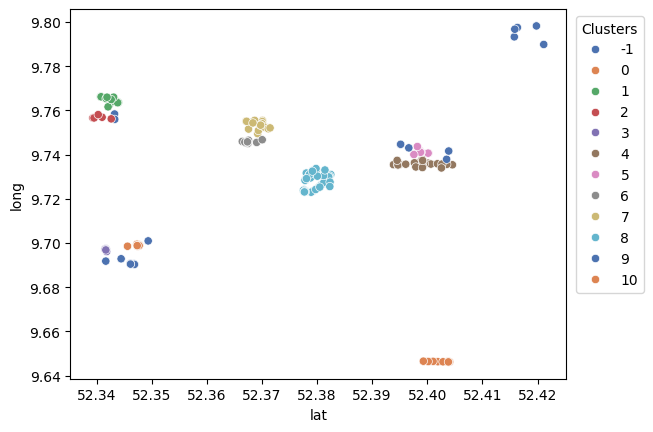

In [5]:
# Now visualize the clusters using a scatter plot with the below code snippet
p = sns.scatterplot(data = df, x = "lat", y = "long", hue = "cluster_id", legend = "full", palette = "deep")
sns.move_legend(p, "upper right", bbox_to_anchor = (1.17, 1.), title = 'Clusters')
plt.show()

**Task 2** Describe you interpretation about the DBSCAN clusters visualised above. (2 Points)

# YOUR INTERPRETATION
The DBSCAN results show many small, fragmented clusters and several falsely detected outliers because the eps parameter was set too low, which drastically limits how close points must be to be considered neighbors.This means accident locations that should naturally form a single dense cluster end up being split into multiple tiny groups, and points that fall just slightly outside this narrow radius are incorrectly labeled as outliers. 

**Task 3** Change the parameter values for eps =0.01, min_samples = 10 and run the above code again. What do you observe? (2 Points)

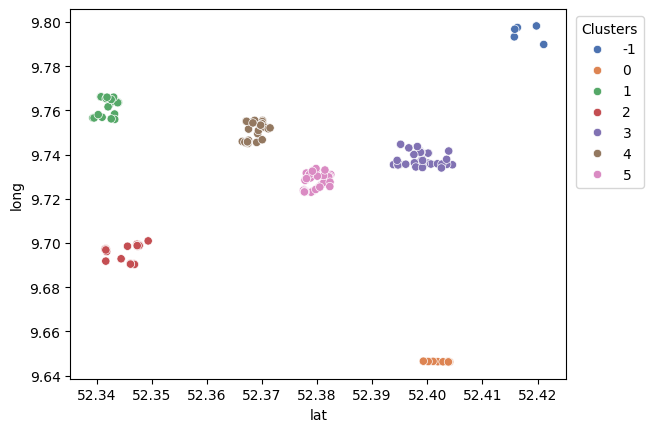

In [9]:
# YOUR CODE HERE
clustering = DBSCAN(eps = 0.01, min_samples = 10)
# Fit DBSCAN on 'coordinates' column
clustering.fit(coordinates) 
# Create a data frame 'df' with "coordinates" column and "cluster_id" column containing cluster labels
df = pd.DataFrame(coordinates, columns = ['lat', 'long'])
df['cluster_id'] = clustering.labels_


# Now visualize the clusters using a scatter plot with the below code snippet
p = sns.scatterplot(data = df, x = "lat", y = "long", hue = "cluster_id", legend = "full", palette = "deep")
sns.move_legend(p, "upper right", bbox_to_anchor = (1.17, 1.), title = 'Clusters')
plt.show()

# YOUR INTERPRETATION
With eps increased to 0.01 and min_samples raised to 10, the clustering becomes much more coherent, producing a smaller number of larger clusters that now align more naturally with the visual groupings in the data. This demonstrates how critical the eps parameter is: a slightly larger neighborhood radius allows DBSCAN to recognize that many points belong to the same dense region, avoiding the artificial fragmentation seen earlier. However, increasing min_samples introduces a different issue. It is now required to have at least 10 nearby points to form a cluster, which causes the small group of points in the top-right corner to be labeled as outliers (-1) even though they clearly form a tight, legitimate cluster.